# Recommendation Systems using Matrix Factorization (SVD & NMF)
# 24BAD099 - Rithish A

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

DATA_DIR = r'd:\class materials AI&DS\sem 4\ML\Lab\EXP-10'
MOVIES_PATH = rf'{DATA_DIR}\movies.csv'
RATINGS_PATH = rf'{DATA_DIR}\ratings.csv'

movies = pd.read_csv(MOVIES_PATH)
ratings = pd.read_csv(RATINGS_PATH)

movies = movies[['movieId', 'title']].drop_duplicates('movieId')
ratings = ratings[['userId', 'movieId', 'rating']].drop_duplicates()

all_user_ids = sorted(ratings['userId'].unique())
all_movie_ids = sorted(pd.Index(ratings['movieId'].unique()).union(movies['movieId'].unique()))

train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

def build_matrix(frame):
    matrix = frame.pivot_table(index='userId', columns='movieId', values='rating', aggfunc='mean')
    matrix = matrix.reindex(index=all_user_ids, columns=all_movie_ids)
    return matrix

train_matrix = build_matrix(train_ratings)
test_matrix = build_matrix(test_ratings)

global_mean = float(train_ratings['rating'].mean())
user_means = train_matrix.mean(axis=1).fillna(global_mean)
centered_train_matrix = train_matrix.sub(user_means, axis=0).fillna(0.0)

train_observed_mask = ~train_matrix.isna()
test_observed_mask = ~test_matrix.isna()

print('Ratings rows:', len(ratings))
print('Train shape:', train_matrix.shape)
print('Test shape:', test_matrix.shape)
print('Sparse density in train:', round(train_observed_mask.values.mean(), 4))
print('Unique users:', ratings['userId'].nunique())
print('Unique movies:', ratings['movieId'].nunique())

Ratings rows: 105339
Train shape: (668, 10329)
Test shape: (668, 10329)
Sparse density in train: 0.0122
Unique users: 668
Unique movies: 10325


In [7]:
def clip_ratings(values):
    return np.clip(values, 0.5, 5.0)


def matrix_to_predictions(frame, global_fill=0.0):
    return frame.reindex(index=train_matrix.index, columns=train_matrix.columns).fillna(global_fill)


def evaluate_on_pairs(prediction_matrix, actual_pairs):
    actual = []
    predicted = []
    for row in actual_pairs.itertuples(index=False):
        user_id = row.userId
        movie_id = row.movieId
        if user_id in prediction_matrix.index and movie_id in prediction_matrix.columns:
            actual.append(float(row.rating))
            predicted.append(float(prediction_matrix.loc[user_id, movie_id]))
    if not actual:
        return {'rmse': np.nan, 'mae': np.nan}
    actual_array = np.asarray(actual)
    predicted_array = clip_ratings(np.asarray(predicted))
    mse = mean_squared_error(actual_array, predicted_array)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(actual_array, predicted_array)
    return {'rmse': rmse, 'mae': mae}


def recommend_top_n(prediction_matrix, user_id, n=10, seen_items=None):
    if user_id not in prediction_matrix.index:
        return pd.DataFrame(columns=['movieId', 'title', 'predicted_rating'])
    scores = prediction_matrix.loc[user_id].copy()
    if seen_items is not None:
        scores = scores.drop(labels=[item for item in seen_items if item in scores.index], errors='ignore')
    ranked = scores.sort_values(ascending=False).head(n).reset_index()
    ranked.columns = ['movieId', 'predicted_rating']
    ranked = ranked.merge(movies, on='movieId', how='left')
    return ranked[['movieId', 'title', 'predicted_rating']]


def recommendation_metrics(prediction_matrix, train_frame, test_frame, top_k=10, relevant_threshold=4.0):
    train_seen = train_frame.groupby('userId')['movieId'].apply(set).to_dict()
    test_relevant = test_frame[test_frame['rating'] >= relevant_threshold].groupby('userId')['movieId'].apply(set).to_dict()

    precisions = []
    recalls = []
    for user_id, relevant_items in test_relevant.items():
        if user_id not in prediction_matrix.index:
            continue
        seen_items = train_seen.get(user_id, set())
        top_items = recommend_top_n(prediction_matrix, user_id, n=top_k, seen_items=seen_items)['movieId'].tolist()
        if not top_items:
            continue
        hits = len(set(top_items).intersection(relevant_items))
        precisions.append(hits / top_k)
        recalls.append(hits / len(relevant_items))

    return {
        'precision_at_k': float(np.mean(precisions)) if precisions else np.nan,
        'recall_at_k': float(np.mean(recalls)) if recalls else np.nan,
    }


def sample_matrix(frame, n_users=30, n_items=30):
    user_subset = frame.index[:n_users]
    item_subset = frame.columns[:n_items]
    return frame.loc[user_subset, item_subset]


def plot_matrix_comparison(original_matrix, reconstructed_matrix, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(original_matrix, cmap='Blues', ax=axes[0], cbar=True)
    axes[0].set_title(f'{title_prefix} - Original Sample')
    axes[0].set_xlabel('Movie Index')
    axes[0].set_ylabel('User Index')

    sns.heatmap(reconstructed_matrix, cmap='magma', ax=axes[1], cbar=True)
    axes[1].set_title(f'{title_prefix} - Reconstructed Sample')
    axes[1].set_xlabel('Movie Index')
    axes[1].set_ylabel('User Index')

    plt.tight_layout()
    plt.show()

## Scenario 1: SVD-based Matrix Factorization

    k    rmse     mae
0   5  3.2003  3.0263
1  10  0.9158  0.7049
2  20  0.9158  0.7045
3  40  0.9219  0.7102
        userId  movieId  rating  predicted_rating
100327     668     1552     3.0             2.725
92474      607     3988     4.0             3.054
95852      627    53996     2.0             3.518
101464     668     4432     4.0             2.810
98004      651     6734     2.0             2.978
19040      149     1265     5.0             4.293
104974     668   100238     3.0             2.787
90579      602     4027     3.5             3.684
41881      297     2792     3.0             3.722
50527      363      724     4.0             3.575


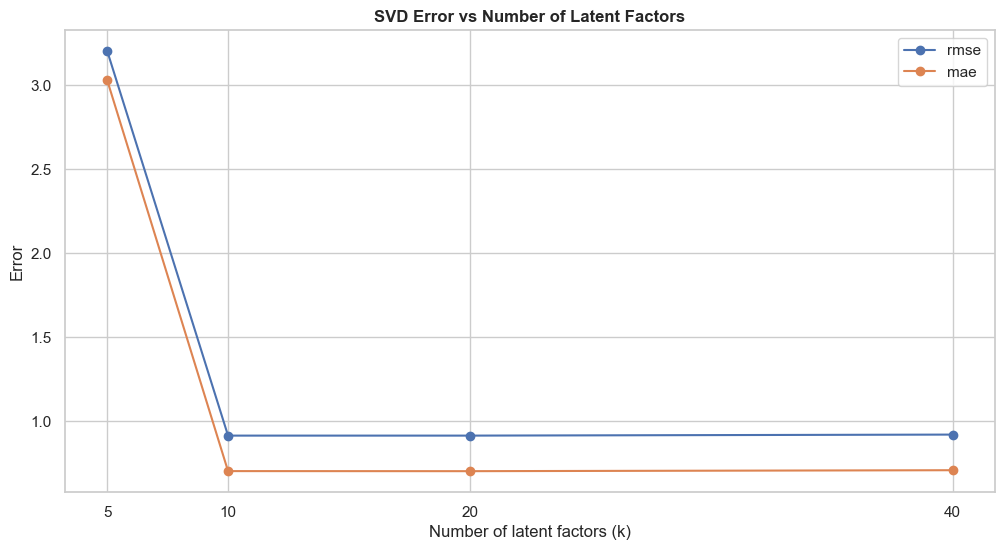

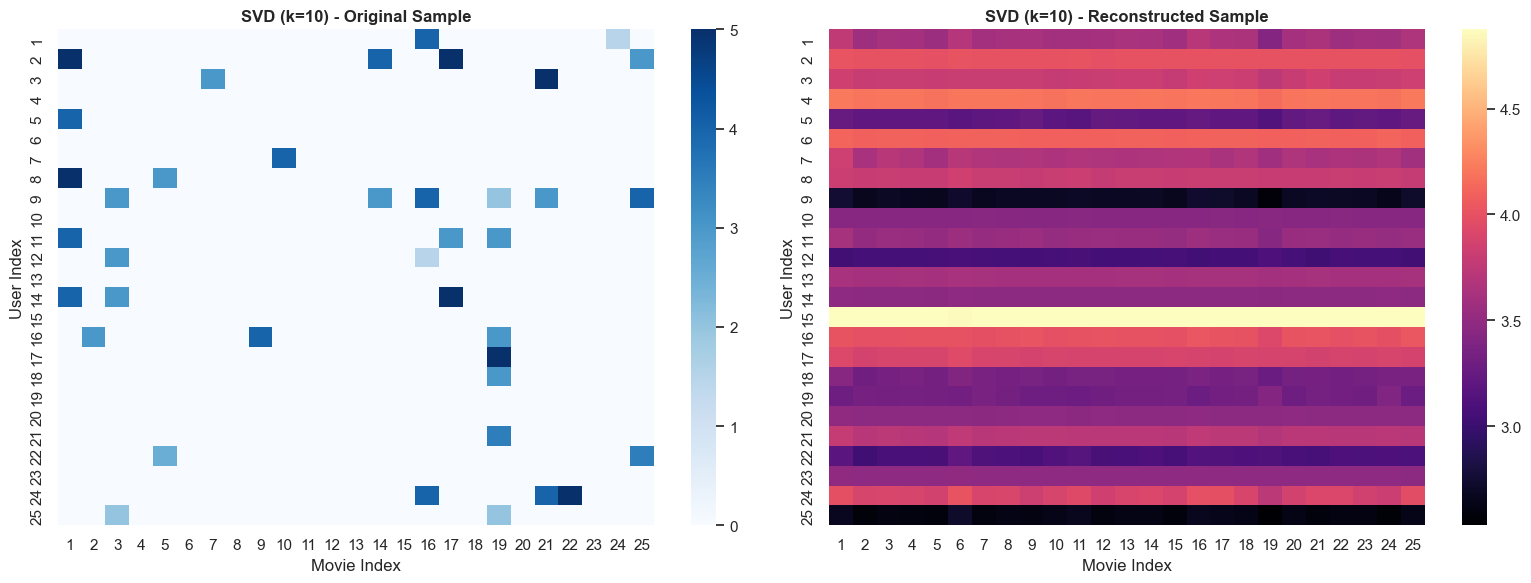

Top recommendations for user 668 using SVD
   movieId                                          title  predicted_rating
0     1219                                  Psycho (1960)          2.917347
1      912                              Casablanca (1942)          2.909780
2     2324     Life Is Beautiful (La Vita è bella) (1997)          2.884258
3     1207                   To Kill a Mockingbird (1962)          2.876611
4      527                        Schindler's List (1993)          2.874390
5     3418                         Thelma & Louise (1991)          2.871082
6      922  Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)          2.868347
7      908                      North by Northwest (1959)          2.867156
8     2393                 Star Trek: Insurrection (1998)          2.864545
9      434                             Cliffhanger (1993)          2.859128


In [8]:
k_values = [5, 10, 20, 40]
svd_results = []
svd_models = {}
svd_predictions = {}

train_centered_values = centered_train_matrix.values

for k in k_values:
    svd_model = TruncatedSVD(n_components=k, random_state=42)
    user_factors = svd_model.fit_transform(train_centered_values)
    reconstructed_centered = user_factors @ svd_model.components_
    svd_prediction_matrix = pd.DataFrame(
        reconstructed_centered,
        index=train_matrix.index,
        columns=train_matrix.columns,
    ).add(user_means, axis=0)
    svd_prediction_matrix = svd_prediction_matrix.clip(lower=0.5, upper=5.0)

    metrics = evaluate_on_pairs(svd_prediction_matrix, test_ratings)
    svd_results.append({'k': k, **metrics})
    svd_models[k] = svd_model
    svd_predictions[k] = svd_prediction_matrix

svd_results_df = pd.DataFrame(svd_results)
svd_results_df['rmse'] = svd_results_df['rmse'].round(4)
svd_results_df['mae'] = svd_results_df['mae'].round(4)
print(svd_results_df)

best_svd_k = int(svd_results_df.sort_values('rmse').iloc[0]['k'])
best_svd_prediction_matrix = svd_predictions[best_svd_k]

sample_test_pairs = test_ratings.sample(n=min(10, len(test_ratings)), random_state=42).copy()
sample_test_pairs['predicted_rating'] = [
    float(best_svd_prediction_matrix.loc[row.userId, row.movieId])
    if row.userId in best_svd_prediction_matrix.index and row.movieId in best_svd_prediction_matrix.columns
    else np.nan
    for row in sample_test_pairs.itertuples(index=False)
]
sample_test_pairs['predicted_rating'] = sample_test_pairs['predicted_rating'].round(3)
print(sample_test_pairs[['userId', 'movieId', 'rating', 'predicted_rating']])

svd_error_by_k = svd_results_df.set_index('k')[['rmse', 'mae']]
svd_error_by_k.plot(marker='o')
plt.title('SVD Error vs Number of Latent Factors')
plt.xlabel('Number of latent factors (k)')
plt.ylabel('Error')
plt.xticks(k_values)
plt.show()

original_sample = sample_matrix(train_matrix.fillna(0.0), 25, 25)
reconstructed_sample = sample_matrix(best_svd_prediction_matrix, 25, 25)
plot_matrix_comparison(original_sample, reconstructed_sample, f'SVD (k={best_svd_k})')

sample_user_id = int(train_ratings.groupby('userId').size().idxmax())
seen_movies = set(train_ratings.loc[train_ratings['userId'] == sample_user_id, 'movieId'])
svd_top_n = recommend_top_n(best_svd_prediction_matrix, sample_user_id, n=10, seen_items=seen_movies)
print(f'Top recommendations for user {sample_user_id} using SVD')
print(svd_top_n)

## Scenario 2: NMF-based Matrix Factorization

    k    rmse     mae
0   5  2.8904  2.6744
1  10  2.8687  2.6502
2  20  2.8870  2.6735
NMF Precision@10: 0.1635
NMF Recall@10: 0.1412


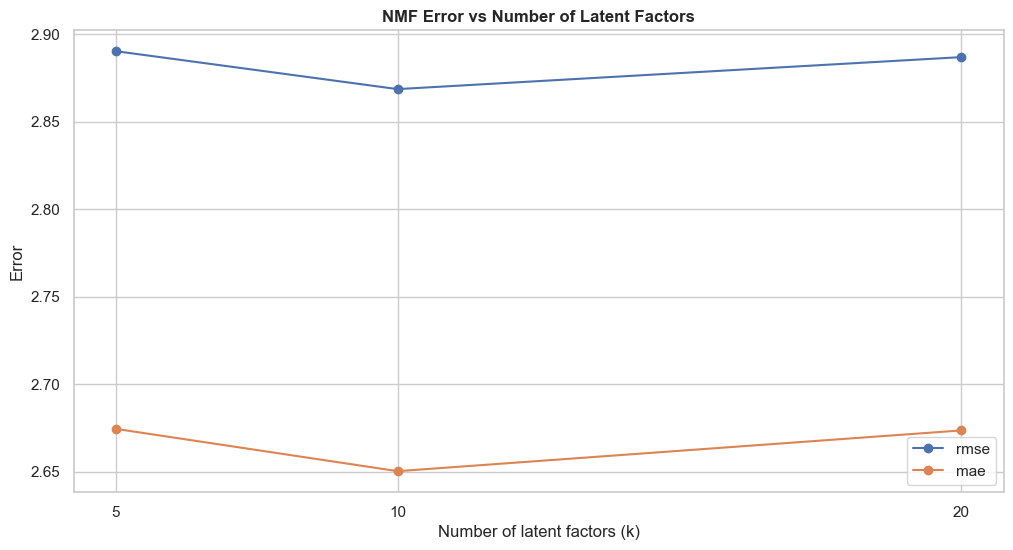

            SVD_RMSE  SVD_MAE  NMF_RMSE  NMF_MAE
Best model    0.9158   0.7045    2.8687   2.6502


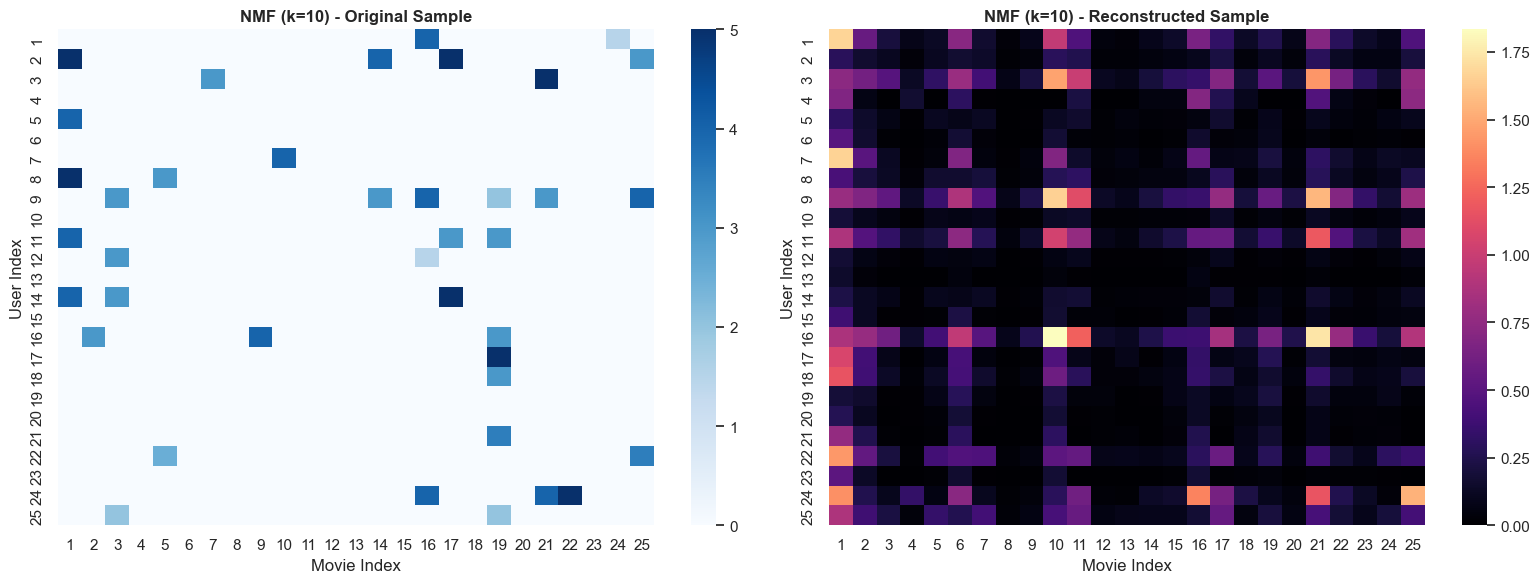

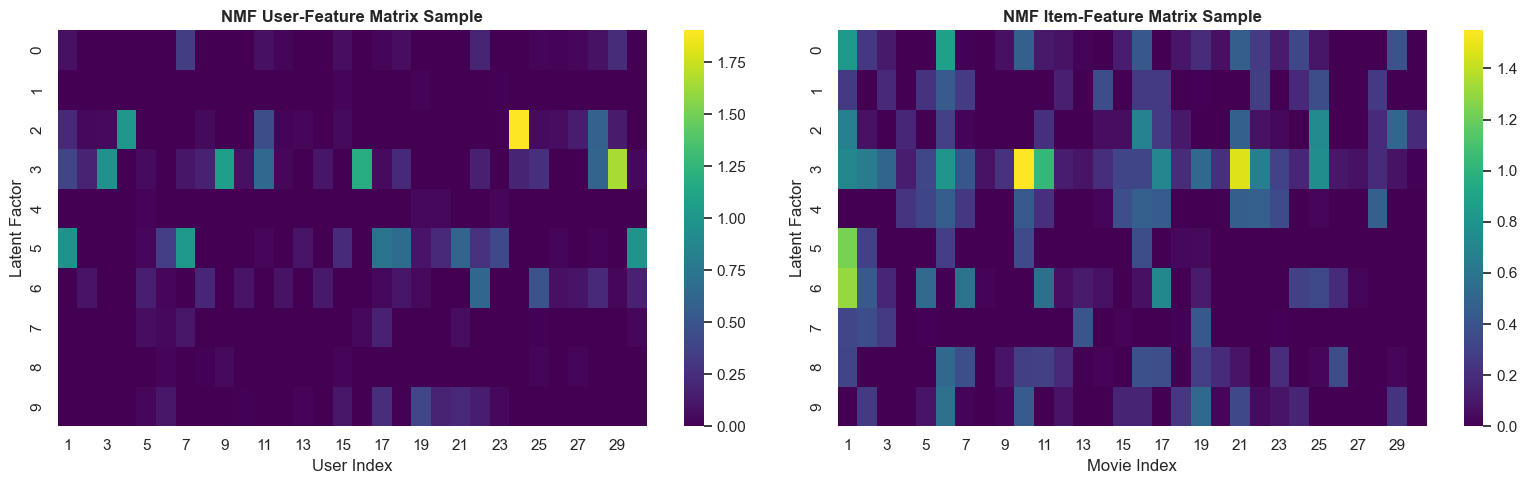

Top recommendations for user 668 using NMF
   movieId                                              title  \
0     3435                            Double Indemnity (1944)   
1    30749                                Hotel Rwanda (2004)   
2     2176                                        Rope (1948)   
3     8228  Maltese Falcon, The (a.k.a. Dangerous Female) ...   
4     6565                                  Seabiscuit (2003)   
5     2644                                     Dracula (1931)   
6      908                          North by Northwest (1959)   
7     1269                        Arsenic and Old Lace (1944)   
8     5945                               About Schmidt (2002)   
9      922      Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)   

   predicted_rating  
0          0.303330  
1          0.302958  
2          0.301503  
3          0.296887  
4          0.275206  
5          0.241999  
6          0.223724  
7          0.217528  
8          0.217323  
9          0.211015  

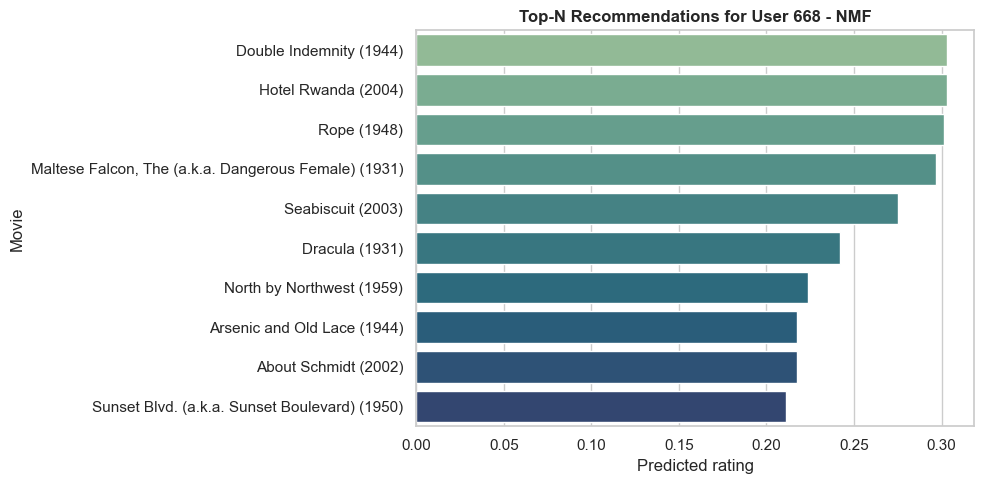

In [10]:
nmf_k_values = [5, 10, 20]
nmf_results = []
nmf_models = {}
nmf_predictions = {}

nmf_input_matrix = train_matrix.fillna(0.0).clip(lower=0.0)

for k in nmf_k_values:
    nmf_model = NMF(
        n_components=k,
        init='nndsvda',
        random_state=42,
        max_iter=1000,
    )
    user_features = nmf_model.fit_transform(nmf_input_matrix)
    item_features = nmf_model.components_
    reconstructed_matrix = pd.DataFrame(
        user_features @ item_features,
        index=train_matrix.index,
        columns=train_matrix.columns,
    ).clip(lower=0.0, upper=5.0)

    metrics = evaluate_on_pairs(reconstructed_matrix, test_ratings)
    nmf_results.append({'k': k, **metrics})
    nmf_models[k] = nmf_model
    nmf_predictions[k] = reconstructed_matrix

nmf_results_df = pd.DataFrame(nmf_results)
nmf_results_df['rmse'] = nmf_results_df['rmse'].round(4)
nmf_results_df['mae'] = nmf_results_df['mae'].round(4)
print(nmf_results_df)

best_nmf_k = int(nmf_results_df.sort_values('rmse').iloc[0]['k'])
best_nmf_prediction_matrix = nmf_predictions[best_nmf_k]
best_nmf_model = nmf_models[best_nmf_k]

nmf_reco_metrics = recommendation_metrics(best_nmf_prediction_matrix, train_ratings, test_ratings, top_k=10)
print('NMF Precision@10:', round(nmf_reco_metrics['precision_at_k'], 4))
print('NMF Recall@10:', round(nmf_reco_metrics['recall_at_k'], 4))

nmf_error_by_k = nmf_results_df.set_index('k')[['rmse', 'mae']]
nmf_error_by_k.plot(marker='o')
plt.title('NMF Error vs Number of Latent Factors')
plt.xlabel('Number of latent factors (k)')
plt.ylabel('Error')
plt.xticks(nmf_k_values)
plt.show()

svd_vs_nmf = pd.DataFrame({
    'SVD_RMSE': [svd_results_df['rmse'].min()],
    'SVD_MAE': [svd_results_df['mae'].min()],
    'NMF_RMSE': [nmf_results_df['rmse'].min()],
    'NMF_MAE': [nmf_results_df['mae'].min()],
}, index=['Best model'])
print(svd_vs_nmf)

original_sample = sample_matrix(train_matrix.fillna(0.0), 25, 25)
nmf_sample = sample_matrix(best_nmf_prediction_matrix, 25, 25)
plot_matrix_comparison(original_sample, nmf_sample, f'NMF (k={best_nmf_k})')

user_feature_frame = pd.DataFrame(best_nmf_model.transform(nmf_input_matrix), index=train_matrix.index)
item_feature_frame = pd.DataFrame(best_nmf_model.components_.T, index=train_matrix.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(user_feature_frame.iloc[:30, :].T, cmap='viridis', ax=axes[0])
axes[0].set_title('NMF User-Feature Matrix Sample')
axes[0].set_xlabel('User Index')
axes[0].set_ylabel('Latent Factor')

sns.heatmap(item_feature_frame.iloc[:30, :].T, cmap='viridis', ax=axes[1])
axes[1].set_title('NMF Item-Feature Matrix Sample')
axes[1].set_xlabel('Movie Index')
axes[1].set_ylabel('Latent Factor')
plt.tight_layout()
plt.show()

sample_user_id = int(train_ratings.groupby('userId').size().idxmax())
seen_movies = set(train_ratings.loc[train_ratings['userId'] == sample_user_id, 'movieId'])
nmf_top_n = recommend_top_n(best_nmf_prediction_matrix, sample_user_id, n=10, seen_items=seen_movies)
print(f'Top recommendations for user {sample_user_id} using NMF')
print(nmf_top_n)

plt.figure(figsize=(10, 5))
sns.barplot(data=nmf_top_n, x='predicted_rating', y='title', palette='crest', hue='title', legend=False)
plt.title(f'Top-N Recommendations for User {sample_user_id} - NMF')
plt.xlabel('Predicted rating')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()